In [1]:
# load data

import pandas as pd

df = pd.read_csv("../outputs/sample_size.csv")

In [2]:
summary = (
    df.groupby("n_samples")
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

In [3]:
summary

,n_samples,mean_r2,sd_r2,mean_mse,sd_mse
0,50,0.335187,0.037730,0.252489,0.014330
1,56,0.329535,0.034350,0.254635,0.013046
2,63,0.322079,0.035114,0.257467,0.013336
3,71,0.299489,0.092321,0.266046,0.035062
4,81,0.333788,0.069952,0.253020,0.026567
5,91,0.354184,0.022130,0.245274,0.008405
6,102,0.383145,0.032876,0.234275,0.012486
7,115,0.331819,0.060848,0.253768,0.023109
8,130,0.372271,0.019820,0.238405,0.007527
9,146,0.380436,0.031262,0.235303,0.011873


Text(0, 0.5, 'Mean MSE')

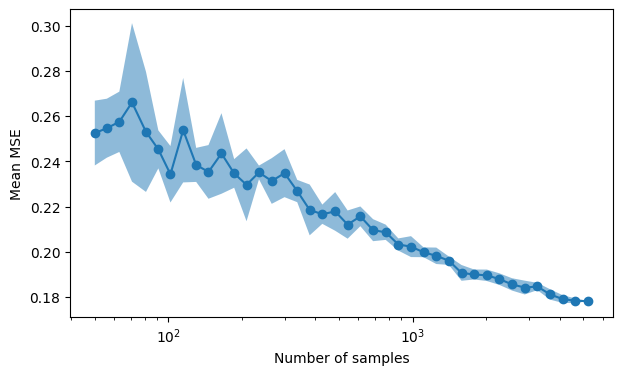

In [4]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

In [5]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [6]:
from scipy.optimize import curve_fit

k = summary["n_samples"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

Text(0, 0.5, 'Mean MSE')

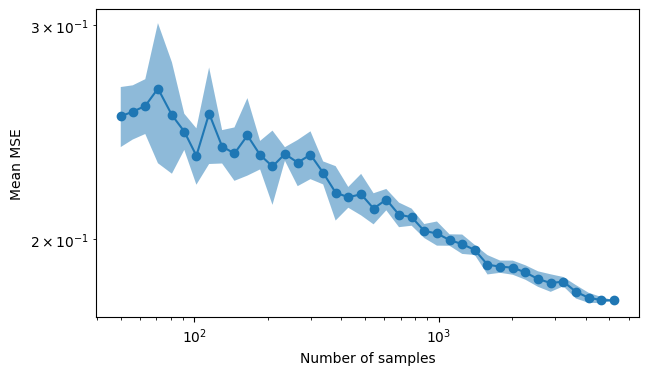

In [7]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

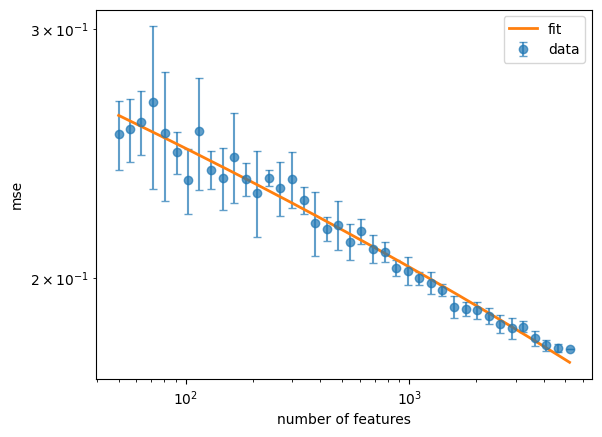

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_smooth = np.linspace(min(k), max(k), 200)


plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="data"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="fit"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("number of features")
plt.ylabel("mse")
plt.legend()
plt.show()

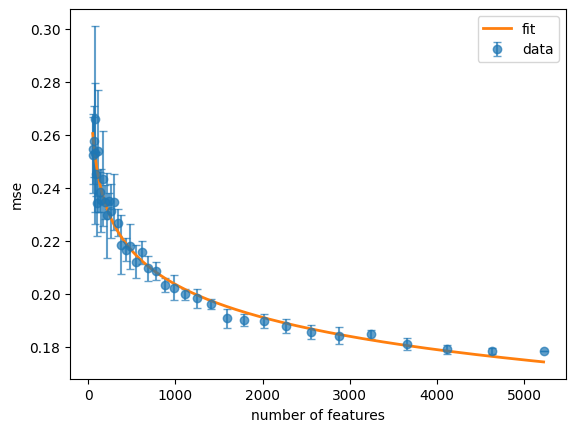

In [9]:

n_smooth = np.linspace(min(k), max(k), 200)


plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="data"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="fit"
)

plt.xlabel("number of features")
plt.ylabel("mse")
plt.legend()
plt.show()